In [4]:
import os
import json
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

In [79]:
XSL_P00_path = '../../../data_products/NGC0613_DATACUBE_FINAL_clean/XSLAgeMh_1/ppxf/'
XSL_PC_path = '../../../data_products/NGC0613_DATACUBE_FINAL_clean/XSLAgeMh/ppxf/'
MILES_BASTI_path = '../../../data_products/NGC0613_DATACUBE_FINAL_clean/MilesAgeMhAlpha/ppxf/'
BITTNER_2020_path = '../../../data/misc_data/all_pops_light/'
BITTNER_ngc613_path = 'NGC613_pops_light.fits'

chi2_filepath = 'chi2.fits'
average_age_filepath = 'average_age.fits'
average_mh_filepath = 'average_metallicity.fits'
average_alpha_filepath = 'average_alpha.fits'
av_filepath = 'a_v.fits'
kinematics_filepath = 'sol.fits'
weights_filepath = 'weights.fits'
metadata_filepath = 'metadata.json'

In [6]:
# Reading average age of the fit

path = os.path.join(XSL_P00_path, average_age_filepath)
with fits.open(path) as hdl:
    average_age_xsl_p00 = hdl[0].data

# Reading data products of fit with XSL Parsec/Colibri    
path = os.path.join(XSL_PC_path, average_age_filepath)
with fits.open(path) as hdl:
    average_age_xsl_pc = hdl[0].data
    
# Reading data products of fit with XSL Parsec/Colibri    
path = os.path.join(MILES_BASTI_path, average_age_filepath)
with fits.open(path) as hdl:
    average_age_miles_basti = hdl[0].data

In [7]:
# Reading average metallicity of the fit

path = os.path.join(XSL_P00_path, average_mh_filepath)
with fits.open(path) as hdl:
    average_mh_xsl_p00 = hdl[0].data

# Reading data products of fit with XSL Parsec/Colibri    
path = os.path.join(XSL_PC_path, average_mh_filepath)
with fits.open(path) as hdl:
    average_mh_xsl_pc = hdl[0].data
    
# Reading data products of fit with XSL Parsec/Colibri    
path = os.path.join(MILES_BASTI_path, average_mh_filepath)
with fits.open(path) as hdl:
    average_mh_miles_basti = hdl[0].data

In [8]:
# Reading weights of the fit

path = os.path.join(XSL_P00_path, weights_filepath)
with fits.open(path) as hdl:
    weights_xsl_p00 = hdl[0].data

# Reading data products of fit with XSL Parsec/Colibri    
path = os.path.join(XSL_PC_path, weights_filepath)
with fits.open(path) as hdl:
    weights_xsl_pc = hdl[0].data
    
# Reading data products of fit with XSL Parsec/Colibri    
path = os.path.join(MILES_BASTI_path, weights_filepath)
with fits.open(path) as hdl:
    weights_miles_basti = hdl[0].data

In [108]:
# Reading Bittne+2020 data products

# There is a difference between the shapes, adding some columns and rows with NaN to try to fix it
# aux = np.full_like(average_mh_xsl_pc, fill_value=np.nan)
# aux[:-1, 2:-5] = metal_bittner

path = os.path.join(BITTNER_2020_path, BITTNER_ngc613_path)
with fits.open(path) as hdl:
    aux = np.full_like(average_mh_xsl_pc, fill_value=np.nan)
    aux[:-1, :-5] = hdl['AGE'].data
    age_bittner22 = aux.copy()
    
    aux = np.full_like(average_mh_xsl_pc, fill_value=np.nan)
    aux[:-1, :-5] = hdl['METAL'].data
    mh_bittner22 = aux.copy()
    
    aux = np.full_like(average_mh_xsl_pc, fill_value=np.nan)
    aux[:-1, :-5] = hdl['ALPHA'].data
    afe_bittner22 = aux.copy()


In [105]:
# Reading average alpha-enhancement of the fit 

try:
    path = os.path.join(XSL_P00_path, average_alpha_filepath)
    with fits.open(path) as hdl:
        average_afe_xsl_p00 = hdl[0].data
except:
    average_afe_xsl_p00 = []

try:
    # Reading data products of fit with XSL Parsec/Colibri    
    path = os.path.join(XSL_PC_path, average_alpha_filepath)
    with fits.open(path) as hdl:
        average_afe_xsl_pc = hdl[0].data
except:
        average_afe_xsl_pc = []

try:
    # Reading data products of fit with XSL Parsec/Colibri    
    path = os.path.join(MILES_BASTI_path, average_alpha_filepath)
    with fits.open(path) as hdl:
        average_afe_miles_basti = hdl[0].data
except:
    average_afe_miles_basti = []

In [10]:
# Reading the metadata the fit with XSL Padova

path = os.path.join(XSL_P00_path, metadata_filepath)
with open(path) as f:
     metadata_xsl_p00 = json.load(f)

# Reading data products of fit with XSL Parsec/Colibri    
path = os.path.join(XSL_PC_path, metadata_filepath)
with open(path) as f:
     metadata_xsl_pc = json.load(f)
    
# Reading data products of fit with XSL Parsec/Colibri    
path = os.path.join(MILES_BASTI_path, metadata_filepath)
with open(path) as f:
    metadata_miles_basti = json.load(f)

In [19]:
# computed average age xsl padova
mh_range = np.array(metadata_xsl_p00['model']['mh_range'])
age_range = np.array(metadata_xsl_p00['model']['age_range'])
# age_range = 10**(age_range-9)
# print(age_range)
reg_dim = np.array(metadata_xsl_p00['model']['reg_dim'])

print(age_range)
print(mh_range)

mh_grid, age_grid = np.meshgrid(mh_range, age_range)
a = np.nansum(weights_xsl_p00 * age_grid.ravel()[:, None, None], 0)
b = np.nansum(weights_xsl_p00, 0)
computed_age_xsl_p00 = 10**((a/b) - 9)
# computed_age_xsl_p00 = a/b


[ 9.    9.05  9.1   9.15  9.2   9.25  9.3   9.35  9.4   9.45  9.5   9.55
  9.6   9.65  9.7   9.75  9.8   9.85  9.9   9.95 10.   10.05 10.1  10.15
 10.2 ]
[-0.7 -0.4  0.   0.2]


/tmp/ipykernel_272949/72406498.py:14: RuntimeWarning: invalid value encountered in divide
  computed_age_xsl_p00 = 10**((a/b) - 9)


In [20]:
# computed average age xsl p/c
mh_range = np.array(metadata_xsl_pc['model']['mh_range'])
age_range = np.array(metadata_xsl_pc['model']['age_range'])
# age_range = 10**(age_range-9)
# print(age_range)
reg_dim = np.array(metadata_xsl_pc['model']['reg_dim'])

print(age_range)
print(mh_range)

mh_grid, age_grid = np.meshgrid(mh_range, age_range)
a = np.nansum(weights_xsl_pc * age_grid.ravel()[:, None, None], 0)
b = np.nansum(weights_xsl_pc, 0)
computed_age_xsl_pc = 10**((a/b) - 9)
# computed_age_xsl_pc = (a/b)


[ 8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7  9.8
  9.9 10.  10.1 10.2]
[-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2]


/tmp/ipykernel_272949/3471078783.py:14: RuntimeWarning: invalid value encountered in divide
  computed_age_xsl_pc = 10**((a/b) - 9)


In [21]:
# computed average age miles basti
mh_range = np.array(metadata_miles_basti['model']['mh_range'])
age_range = np.array(metadata_miles_basti['model']['age_range'])
alpha_range = np.array(metadata_miles_basti['model']['alpha_range'])
reg_dim = np.array(metadata_miles_basti['model']['reg_dim'])

print(age_range)
print(mh_range)

mh_grid, age_grid, alpha_grid = np.meshgrid(mh_range, age_range, alpha_range)
a = np.nansum(weights_miles_basti * age_grid.ravel()[:, None, None], 0)
b = np.nansum(weights_miles_basti, 0)
computed_age_miles_basti = a/b

[ 0.03  0.04  0.05  0.06  0.07  0.08  0.09  0.1   0.15  0.2   0.25  0.3
  0.35  0.4   0.45  0.5   0.6   0.7   0.8   0.9   1.    1.25  1.5   1.75
  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75  4.    4.5   5.    5.5
  6.    6.5   7.    7.5   8.    8.5   9.    9.5  10.   10.5  11.   11.5
 12.   12.5  13.   13.5  14.  ]
[-1.79 -0.96 -0.66 -0.35 -0.25  0.06  0.15  0.26  0.4 ]


/tmp/ipykernel_272949/2518122277.py:13: RuntimeWarning: invalid value encountered in divide
  computed_age_miles_basti = a/b


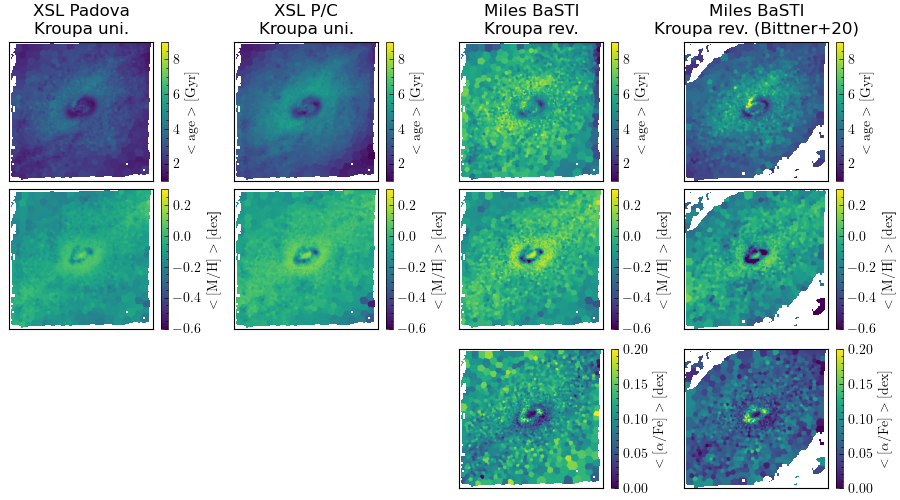

In [109]:
%matplotlib widget

fig, ax = plt.subplots(3, 4, figsize=(9, 5), constrained_layout=True, sharey=True, sharex=True)

for i, data in enumerate([computed_age_xsl_p00, computed_age_xsl_pc, computed_age_miles_basti,
                          age_bittner22]):
    with plt.style.context('science'):
        # Plot <age>
        kwargs = {'origin': 'lower', 'vmin': 1, 'vmax': 9,
                 }

        im = ax[0, i].imshow(data,**kwargs )
        cb = plt.colorbar(im, ax=ax[0, i])
        cb.set_label(r'$<\rm{age}> [\rm{Gyr}]$',)
        # cb.ax.tick_params(rotation=90)
        ax[0, i].axes.get_yaxis().set_visible(False)
        ax[0, i].axes.get_xaxis().set_visible(False)

for i, data in enumerate([average_mh_xsl_p00, average_mh_xsl_pc, average_mh_miles_basti,
                          mh_bittner22]):
    with plt.style.context('science'):
        # Plot <[M/H]>
        kwargs = {'origin': 'lower', 'vmin': -0.6, 'vmax': 0.3,
                 }

        im = ax[1, i].imshow(data, **kwargs)
        cb = plt.colorbar(im, ax=ax[1, i])
        cb.set_label(r'$<[\rm{M/H}]> [\rm{dex}$]')
        # cb.ax.tick_params(rotation=90)
        ax[1, i].axes.get_yaxis().set_visible(False)
        ax[1, i].axes.get_xaxis().set_visible(False)
        

for i, data in enumerate([average_afe_xsl_p00, average_afe_xsl_pc, average_afe_miles_basti,
                          afe_bittner22]):
    with plt.style.context('science'):
        # Plot <[alpha/Fe]>
        kwargs = {'origin': 'lower', 'vmin': 0,'vmax': 0.2, 
                 }

        try:
            im = ax[2, i].imshow(data, **kwargs)
            cb = plt.colorbar(im, ax=ax[2, i])
            cb.set_label(r'$<[\rm{\alpha/Fe]}> [\rm{dex}]$')
            # cb.ax.tick_params(rotation=90)
            ax[2, i].axes.get_yaxis().set_visible(False)
            ax[2, i].axes.get_xaxis().set_visible(False)
        except:
            ax[2,i].axis('off')
         
    ax[0, 0].set_title('XSL Padova\nKroupa uni.')
    ax[0, 1].set_title('XSL P/C\nKroupa uni.')
    ax[0, 2].set_title('Miles BaSTI\nKroupa rev.')
    ax[0, 3].set_title('Miles BaSTI\nKroupa rev. (Bittner+20)')
                                   

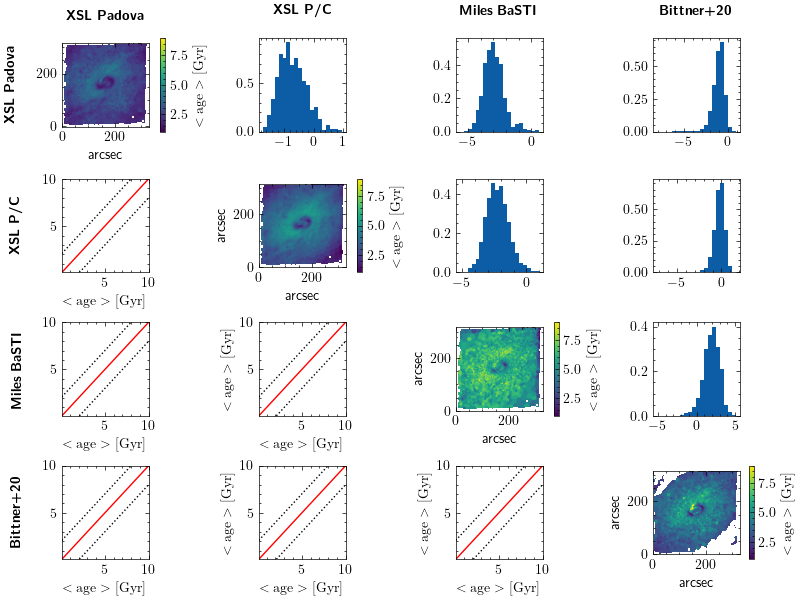

In [238]:
import itertools

a = [computed_age_xsl_p00, computed_age_xsl_pc, computed_age_miles_basti, age_bittner22]

with plt.style.context('science'):
    fig, ax = plt.subplots(4,4, figsize=(8, 6), constrained_layout=True)
    fontsize= 10
    
    for data, n in zip(itertools.product(a, repeat=2), np.ndindex(4,4)):
        if n[0] > n[1]:
            # cmap = 'inferno'
            # im = ax[n].imshow(data[0] - data[1], origin='lower', cmap=cmap
            #                   # , vmin=-5, vmax=5
            #                  )
            # cbar = plt.colorbar(im, ax=ax[n])
            # cbar.set_label(r'$\Delta<\rm{age}> [\rm{Gyr}]$')
            
            ax[n].scatter(data[0], data[1], s=0.0001, alpha=0.1)
            
            diff = 2
            ax[n].plot(np.arange(0.1, 10, 1e-2), np.arange(0.1, 10, 1e-2), color='red')
            ax[n].plot(np.arange(0.1+diff, 10+diff, 1e-2), np.arange(0.1, 10, 1e-2), color='black', ls='dotted', label=rf'$\pm${diff}~Gyr')
            ax[n].plot(np.arange(0.1-diff, 10-diff, 1e-2), np.arange(0.1, 10, 1e-2), color='black', ls='dotted')
            
            ax[n].set_ylabel(r'$<\rm{age}> [\rm{Gyr}]$')
            ax[n].set_xlabel(r'$<\rm{age}> [\rm{Gyr}]$')
            
            ax[n].set_ylim(0.1, 10)
            ax[n].set_xlim(0.1, 10)

        if n[0] < n[1]:
            pass
            ax[n].hist((data[0] - data[1]).ravel(), bins=20, density=True)
        if n[0] == n[1]:
            pass
            im = ax[n].imshow(data[0], origin='lower', vmin=1, vmax=9)
            cbar = plt.colorbar(im, ax=ax[n])
            cbar.set_label(r'$<\rm{age}> [\rm{Gyr}]$')
            
            ax[n].set_ylabel('arcsec')
            ax[n].set_xlabel('arcsec')

        # ax[n].axes.get_yaxis().set_visible(False)
        # ax[n].axes.get_xaxis().set_visible(False)

    ax[0, 0].set_title('$\\textbf{XSL Padova}$\n', fontsize=fontsize)
    ax[0, 1].set_title('$\\textbf{XSL P/C}$\n', fontsize=fontsize)
    ax[0, 2].set_title('$\\textbf{Miles BaSTI}$\n', fontsize=fontsize)
    ax[0, 3].set_title('$\\textbf{Bittner+20}$\n', fontsize=fontsize)

    ax[0, 0].set_ylabel('$\\textbf{XSL Padova}$\n', fontsize=fontsize)
    ax[1, 0].set_ylabel('$\\textbf{XSL P/C}$\n', fontsize=fontsize)
    ax[2, 0].set_ylabel('$\\textbf{Miles BaSTI}$\n', fontsize=fontsize)
    ax[3, 0].set_ylabel('$\\textbf{Bittner+20}$\n', fontsize=fontsize)
